# Project 11: Bias-Resistant Visual Question Answering with Image-Question Fusion

**Dataset:** VQA v2  
**Task:** Yes/No Visual Question Answering  
**Models Compared:** Text-only, Image-only, Fusion  
**Goal:** To test whether the model uses visual information or relies mainly on question bias.

**Team Members**
1) Mihir Rami
2) Luv Patel
3) Sujal Patel


## Problem Statement

Visual question answering systems can exploit language priors and answer common questions without properly using the image. This project compares image-only, text-only, and fused models to measure how much visual grounding is actually used. It is medium difficulty because strong baselines can be built with frozen image and text encoders before attempting full fine-tuning.

Visual Question Answering systems may answer questions using language patterns instead of actually looking at the image.

This project compares three approaches:

- Text-only model
- Image-only model using ResNet18
- Fusion model using both question and image features

The main question is:

**Does adding image information improve prediction compared to using question text alone?**

In [1]:
import os

# Project Name
project_name = "Project11_Bias_Resistant_VQA"

# Folder Structure
folders = [
    f"{project_name}/data/annotations",
    f"{project_name}/data/questions",
    f"{project_name}/data/images",
    f"{project_name}/data/processed",

    f"{project_name}/models/text_model",
    f"{project_name}/models/image_model",
    f"{project_name}/models/fusion_model",

    f"{project_name}/outputs/figures",
    f"{project_name}/outputs/tables",
    f"{project_name}/outputs/confusion_matrix",
    f"{project_name}/outputs/predictions",

    f"{project_name}/reports",
    f"{project_name}/presentation"
]

# Create folders
for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Create empty files
files = ["README.md", "requirements.txt", ".gitignore"]

for file in files:
    open(os.path.join(project_name, file), "w").close()

print("Project folder structure created successfully!")

Project folder structure created successfully!


## Dataset and Subset Justification

The original VQA v2 dataset is large and computationally expensive.

Due to time and hardware limitations, this project uses a carefully selected Yes/No subset from the VQA v2 validation dataset.

Final dataset used:

- 777 image-question pairs
- 545 unique images
- 414 "No" answers
- 363 "Yes" answers

This subset is suitable because the project goal is to compare text-only, image-only, and fusion models rather than train a full-scale VQA system.

## Methodology

The workflow is:

1. Load VQA v2 annotations and questions.
2. Filter only Yes/No questions.
3. Download only the required COCO validation images.
4. Perform exploratory data analysis.
5. Split data into training and testing sets.
6. Train a text-only baseline using TF-IDF and Logistic Regression.
7. Extract image features using pretrained frozen ResNet18.
8. Train an image-only model using ResNet18 features.
9. Combine text and image features for a fusion model.
10. Compare models using accuracy, precision, recall, F1-score, and confusion matrix.
11. Perform error analysis.

In [4]:
import os
import json
import pandas as pd
import numpy as np
import random

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_DIR = "Project11_Bias_Resistant_VQA"

ANNOTATION_PATH = os.path.join(
    PROJECT_DIR, "data", "annotations", "v2_mscoco_val2014_annotations.json"
)

QUESTION_PATH = os.path.join(
    PROJECT_DIR, "data", "questions", "v2_OpenEnded_mscoco_val2014_questions.json"
)

print("Annotation exists:", os.path.exists(ANNOTATION_PATH))
print("Question exists:", os.path.exists(QUESTION_PATH))

Annotation exists: True
Question exists: True


In [5]:
with open(ANNOTATION_PATH, "r") as f:
    annotations_data = json.load(f)

with open(QUESTION_PATH, "r") as f:
    questions_data = json.load(f)

print("Annotation Keys :", annotations_data.keys())
print("Question Keys   :", questions_data.keys())

print("\nTotal Annotations :", len(annotations_data["annotations"]))
print("Total Questions   :", len(questions_data["questions"]))

Annotation Keys : dict_keys(['info', 'license', 'data_subtype', 'annotations', 'data_type'])
Question Keys   : dict_keys(['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions'])

Total Annotations : 214354
Total Questions   : 214354


In [6]:
question_dict = {
    q["question_id"]: q
    for q in questions_data["questions"]
}

print("Question Dictionary Created")
print("Total Questions :", len(question_dict))

Question Dictionary Created
Total Questions : 214354


In [8]:
rows = []

for ann in annotations_data["annotations"]:

    answer = ann["multiple_choice_answer"].lower().strip()

    if answer in ["yes", "no"]:

        qid = ann["question_id"]

        question = question_dict[qid]["question"]

        rows.append({

            "question_id": qid,
            "image_id": ann["image_id"],
            "question": question.lower(),
            "answer": answer,
            "label": 1 if answer == "yes" else 0

        })

df = pd.DataFrame(rows)

print("Total Yes/No Samples :", len(df))
df.head()

Total Yes/No Samples : 80810


,question_id,image_id,question,answer,label
0,393225001,393225,is this a creamy soup?,no,0
1,393225002,393225,is this rice noodle soup?,yes,1
2,240301000,240301,why is there a gap between the roof and wall?,yes,1
3,240301001,240301,is it daylight in this picture?,yes,1
4,131089001,131089,did the batter hit the ball?,yes,1


In [9]:
YES_SAMPLES = 5000
NO_SAMPLES = 5000

yes_df = df[df["answer"] == "yes"].sample(
    n=min(YES_SAMPLES, len(df[df["answer"] == "yes"])),
    random_state=RANDOM_SEED
)

no_df = df[df["answer"] == "no"].sample(
    n=min(NO_SAMPLES, len(df[df["answer"] == "no"])),
    random_state=RANDOM_SEED
)

balanced_df = pd.concat([yes_df, no_df])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print("Balanced Dataset Size :", len(balanced_df))
print()

print(balanced_df["answer"].value_counts())

Balanced Dataset Size : 10000

answer
no     5000
yes    5000
Name: count, dtype: int64


In [10]:
processed_path = os.path.join(
    PROJECT_DIR,
    "data",
    "processed",
    "vqa_yes_no_subset.csv"
)

balanced_df.to_csv(processed_path, index=False)

print("Dataset Saved Successfully")
print(processed_path)

Dataset Saved Successfully
Project11_Bias_Resistant_VQA\data\processed\vqa_yes_no_subset.csv


In [11]:
balanced_df.sample(10)

,question_id,image_id,question,answer,label
6252,329447002,329447,are these milking cows?,no,0
4684,522418003,522418,is the lady holding the knife right?,no,0
1731,179711002,179711,are there any clouds?,yes,1
4742,415990007,415990,is it a hot day?,no,0
4521,269606001,269606,are these rams?,yes,1
6340,104345020,104345,are the lights on?,no,0
576,344521039,344521,are the strawberries sliced?,no,0
5202,463802000,463802,is that a giant bear?,no,0
6363,37875013,37875,is this child being taught the value of patrio...,no,0
439,66524003,66524,is the catcher ready to receive a pitch?,no,0


In [12]:
print("Balanced Dataset Size :", len(balanced_df))
print(balanced_df["answer"].value_counts())

Balanced Dataset Size : 10000
answer
no     5000
yes    5000
Name: count, dtype: int64


In [14]:
import os
import requests
from tqdm import tqdm

IMAGE_DIR = os.path.join(PROJECT_DIR, "data", "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

unique_image_ids = balanced_df["image_id"].unique()

print("Unique images needed:", len(unique_image_ids))

Unique images needed: 8409


In [16]:
def coco_val2014_url(image_id):
    image_name = f"COCO_val2014_{int(image_id):012d}.jpg"
    return image_name, f"http://images.cocodataset.org/val2014/{image_name}"

downloaded = 0
failed = []

for image_id in tqdm(unique_image_ids):
    image_name, url = coco_val2014_url(image_id)
    save_path = os.path.join(IMAGE_DIR, image_name)

    if os.path.exists(save_path):
        continue

    try:
        response = requests.get(url, timeout=10)

        if response.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(response.content)
            downloaded += 1
        else:
            failed.append(image_id)

    except Exception:
        failed.append(image_id)

print("Downloaded:", downloaded)
print("Failed:", len(failed))

  6%|▋         | 545/8409 [00:30<07:21, 17.80it/s]  


KeyboardInterrupt: 

In [17]:
import os

IMAGE_DIR = os.path.join(PROJECT_DIR, "data", "images")

downloaded_images = os.listdir(IMAGE_DIR)
print("Images downloaded:", len(downloaded_images))

Images downloaded: 545


In [18]:
downloaded_image_ids = []

for filename in downloaded_images:
    if filename.endswith(".jpg"):
        image_id = int(filename.replace("COCO_val2014_", "").replace(".jpg", ""))
        downloaded_image_ids.append(image_id)

downloaded_image_ids = set(downloaded_image_ids)

balanced_df = balanced_df[balanced_df["image_id"].isin(downloaded_image_ids)].reset_index(drop=True)

print("Final usable dataset size:", len(balanced_df))
print(balanced_df["answer"].value_counts())

Final usable dataset size: 777
answer
no     414
yes    363
Name: count, dtype: int64


In [19]:
processed_path = os.path.join(
    PROJECT_DIR,
    "data",
    "processed",
    "vqa_yes_no_subset_with_images.csv"
)

balanced_df.to_csv(processed_path, index=False)

print("Saved:", processed_path)

Saved: Project11_Bias_Resistant_VQA\data\processed\vqa_yes_no_subset_with_images.csv


In [20]:
balanced_df = balanced_df[
    balanced_df["image_id"].isin(downloaded_image_ids)
].reset_index(drop=True)

print("Number of samples:", len(balanced_df))
print("Number of unique images:", balanced_df["image_id"].nunique())

balanced_df["answer"].value_counts()

Number of samples: 777
Number of unique images: 545


answer
no     414
yes    363
Name: count, dtype: int64

# 3. Exploratory Data Analysis (EDA)

In [21]:
print("=" * 50)
print("Dataset Information")
print("=" * 50)

print(f"Total Samples : {len(balanced_df)}")
print(f"Unique Images : {balanced_df['image_id'].nunique()}")

print("\nAnswer Distribution:")
print(balanced_df["answer"].value_counts())

print("\nMissing Values:")
print(balanced_df.isnull().sum())

Dataset Information
Total Samples : 777
Unique Images : 545

Answer Distribution:
answer
no     414
yes    363
Name: count, dtype: int64

Missing Values:
question_id    0
image_id       0
question       0
answer         0
label          0
dtype: int64


In [23]:
balanced_df.head(10)

,question_id,image_id,question,answer,label
0,529215001,529215,do you see any animals coming from the woods?,no,0
1,345787000,345787,is this the right dress for her?,yes,1
2,218926002,218926,is this doll wearing a belt?,yes,1
3,145824001,145824,would it be easier for the man to go the other...,yes,1
4,157866001,157866,is the stove built in?,yes,1
5,140661016,140661,is there a fan moving in this picture?,no,0
6,170129008,170129,is the sun bright?,yes,1
7,345063000,345063,has the sign been defaced?,no,0
8,476715000,476715,is this room clean?,no,0
9,300039003,300039,are we bored in this pic?,yes,1


In [24]:
balanced_df["question_length"] = balanced_df["question"].apply(lambda x: len(x.split()))

balanced_df[["question","question_length"]].head()

,question,question_length
0,do you see any animals coming from the woods?,9
1,is this the right dress for her?,7
2,is this doll wearing a belt?,6
3,would it be easier for the man to go the other...,12
4,is the stove built in?,5


C:\Users\morij\AppData\Local\Temp\ipykernel_11272\4245273470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


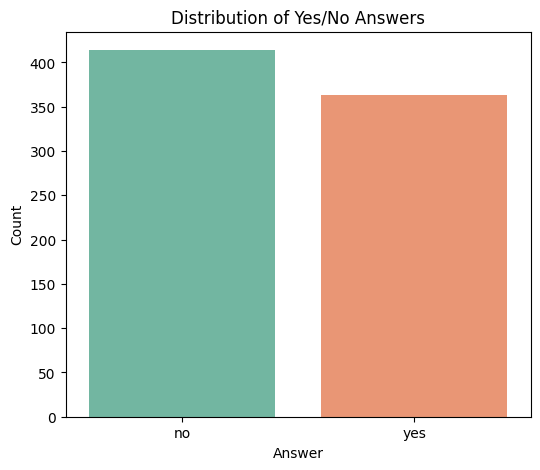

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    data=balanced_df,
    x="answer",
    palette="Set2"
)

plt.title("Distribution of Yes/No Answers")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "figures",
        "answer_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

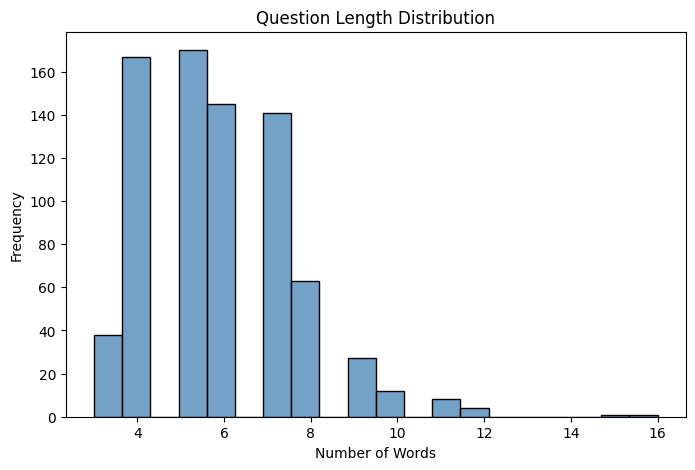

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    balanced_df["question_length"],
    bins=20,
    color="steelblue"
)

plt.title("Question Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "figures",
        "question_length_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
from collections import Counter

all_words = " ".join(balanced_df["question"]).split()

counter = Counter(all_words)

common_words = counter.most_common(20)

word_df = pd.DataFrame(common_words, columns=["Word","Frequency"])

word_df

,Word,Frequency
0,the,489
1,is,483
2,a,250
3,this,213
4,are,152
5,there,138
6,in,133
7,on,73
8,does,52
9,of,38


C:\Users\morij\AppData\Local\Temp\ipykernel_11272\2401517908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


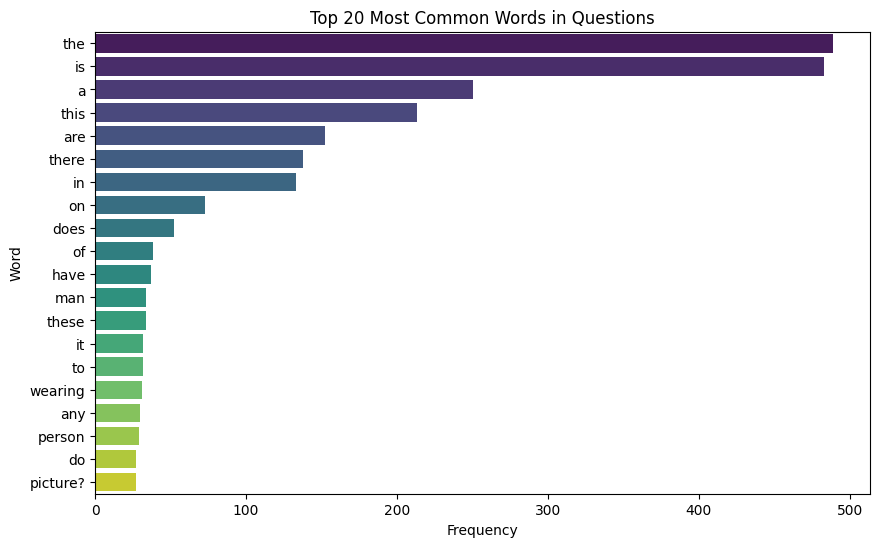

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=word_df,
    x="Frequency",
    y="Word",
    palette="viridis"
)

plt.title("Top 20 Most Common Words in Questions")

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "figures",
        "top20_words.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
balanced_df.to_csv(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "tables",
        "dataset_used.csv"
    ),
    index=False
)

print("EDA Completed Successfully")

EDA Completed Successfully


# 4. Train-Test Split

In [31]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.20,
    random_state=42,
    stratify=balanced_df["label"]
)

print("Training Samples :", len(train_df))
print("Testing Samples  :", len(test_df))

Training Samples : 621
Testing Samples  : 156


In [32]:
print("Training Distribution")
print(train_df["answer"].value_counts())

print("\nTesting Distribution")
print(test_df["answer"].value_counts())

Training Distribution
answer
no     331
yes    290
Name: count, dtype: int64

Testing Distribution
answer
no     83
yes    73
Name: count, dtype: int64


## Selected Models

### Text-only Model
- Uses only the question text.
- TF-IDF converts questions into numerical features.
- Logistic Regression predicts Yes/No.
- This baseline checks whether question patterns alone can predict answers.

### Image-only Model
- Uses only image information.
- Pretrained ResNet18 extracts 512 image features.
- Logistic Regression predicts Yes/No.
- This checks how much signal is available from the image alone.

### Fusion Model
- Combines TF-IDF question features and ResNet18 image features.
- Tests whether using both modalities improves performance.

# 5. Text-Only Baseline (TF-IDF + Logistic Regression)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_text = tfidf.fit_transform(train_df["question"])
X_test_text = tfidf.transform(test_df["question"])

y_train = train_df["label"]
y_test = test_df["label"]

print(X_train_text.shape)
print(X_test_text.shape)

(621, 747)
(156, 747)


In [34]:
from sklearn.linear_model import LogisticRegression

text_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

text_model.fit(X_train_text, y_train)

print("Text Model Trained Successfully!")

Text Model Trained Successfully!


In [36]:
from sklearn.metrics import accuracy_score

text_predictions = text_model.predict(X_test_text)

text_accuracy = accuracy_score(
    y_test,
    text_predictions
)

print(f"Text Model Accuracy : {text_accuracy:.4f}")

Text Model Accuracy : 0.5256


In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        text_predictions,
        target_names=["No","Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.55      0.64      0.59        83
         Yes       0.49      0.40      0.44        73

    accuracy                           0.53       156
   macro avg       0.52      0.52      0.51       156
weighted avg       0.52      0.53      0.52       156



In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    text_predictions
)

cm

array([[53, 30],
       [44, 29]])

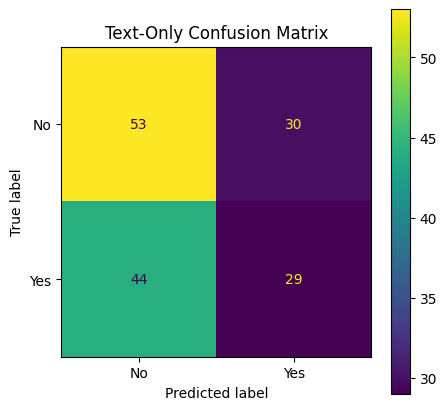

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No","Yes"]
)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(ax=ax)

plt.title("Text-Only Confusion Matrix")

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "confusion_matrix",
        "text_model_cm.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
results = pd.DataFrame({
    "Model": ["Text Only"],
    "Accuracy": [text_accuracy]
})

results

,Model,Accuracy
0,Text Only,0.525641


In [42]:
print(text_accuracy)

0.5256410256410257


# 6. Image-Only Model

In [43]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [44]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove final classification layer
resnet18 = nn.Sequential(*list(resnet18.children())[:-1])

resnet18 = resnet18.to(device)
resnet18.eval()

print("ResNet18 loaded as feature extractor.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\morij/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:24<00:00, 1.92MB/s]


ResNet18 loaded as feature extractor.


In [45]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [46]:
def get_image_path(image_id):
    image_name = f"COCO_val2014_{int(image_id):012d}.jpg"
    return os.path.join(PROJECT_DIR, "data", "images", image_name)

In [47]:
def extract_image_features(df):
    features = []

    for image_id in tqdm(df["image_id"]):
        image_path = get_image_path(image_id)

        image = Image.open(image_path).convert("RGB")
        image_tensor = image_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            feature = resnet18(image_tensor)

        feature = feature.squeeze().cpu().numpy()
        features.append(feature)

    return np.array(features)

X_train_img = extract_image_features(train_df)
X_test_img = extract_image_features(test_df)

print("Train image features:", X_train_img.shape)
print("Test image features:", X_test_img.shape)

100%|██████████| 156/156 [00:15<00:00,  9.92it/s]

Train image features: (621, 512)
Test image features: (156, 512)


In [48]:
np.save(os.path.join(PROJECT_DIR, "data", "processed", "X_train_img.npy"), X_train_img)
np.save(os.path.join(PROJECT_DIR, "data", "processed", "X_test_img.npy"), X_test_img)

print("Image features saved.")

Image features saved.


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

image_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

image_model.fit(X_train_img, y_train)

image_predictions = image_model.predict(X_test_img)

image_accuracy = accuracy_score(y_test, image_predictions)

print(f"Image-Only Accuracy: {image_accuracy:.4f}")

Image-Only Accuracy: 0.5064


In [51]:
print(
    classification_report(
        y_test,
        image_predictions,
        target_names=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.54      0.53      0.53        83
         Yes       0.47      0.48      0.48        73

    accuracy                           0.51       156
   macro avg       0.50      0.50      0.50       156
weighted avg       0.51      0.51      0.51       156



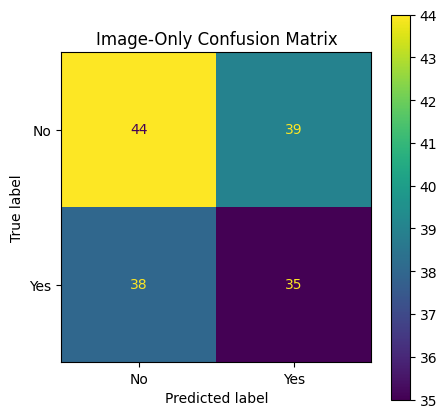

In [52]:
cm_img = confusion_matrix(y_test, image_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_img,
    display_labels=["No", "Yes"]
)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax)

plt.title("Image-Only Confusion Matrix")

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "confusion_matrix",
        "image_model_cm.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
print(image_accuracy)

0.5064102564102564


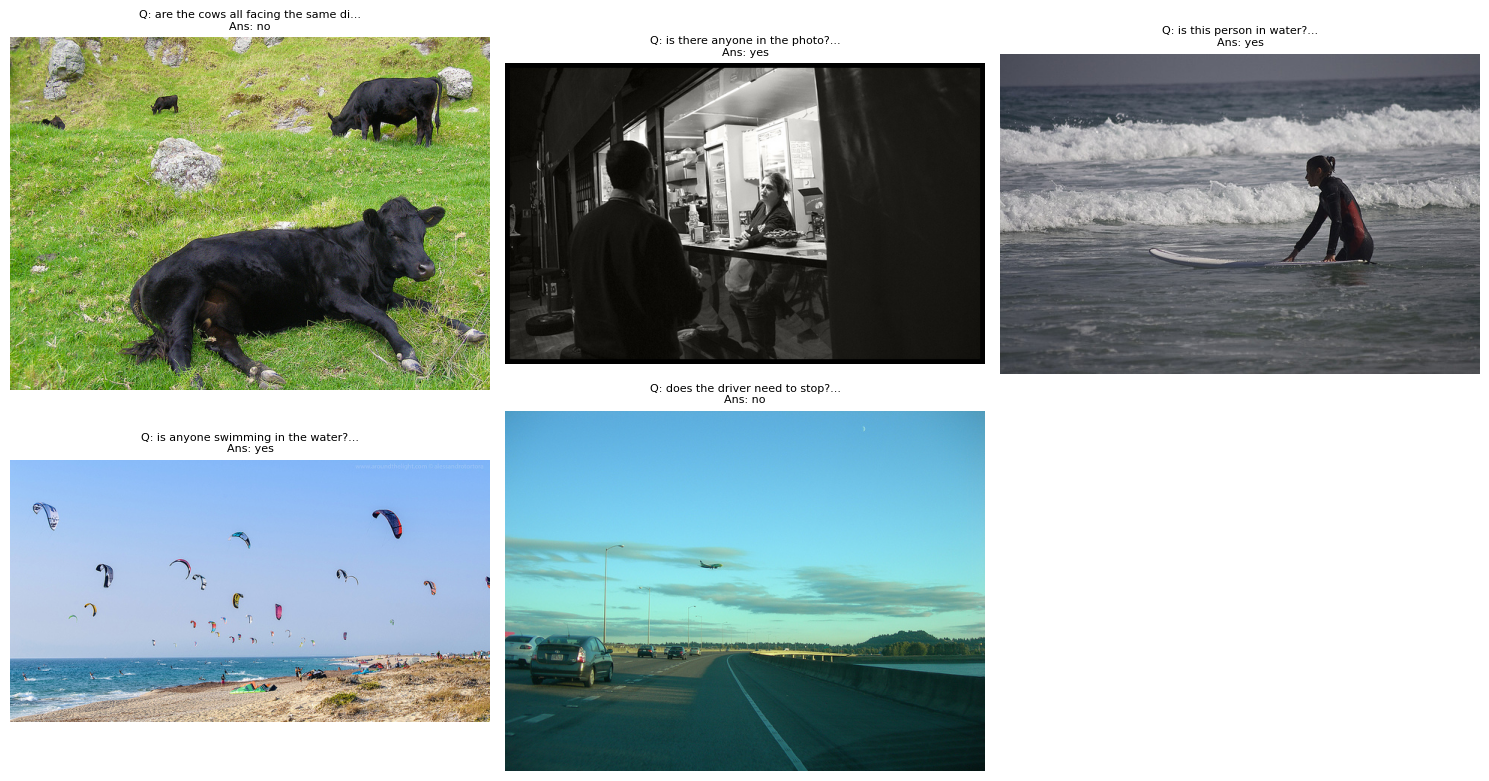

In [29]:
from PIL import Image

sample = balanced_df.sample(5, random_state=42)

plt.figure(figsize=(15,8))

for i, (_, row) in enumerate(sample.iterrows()):

    image_name = f"COCO_val2014_{int(row['image_id']):012d}.jpg"

    image_path = os.path.join(
        PROJECT_DIR,
        "data",
        "images",
        image_name
    )

    plt.subplot(2,3,i+1)

    if os.path.exists(image_path):
        img = Image.open(image_path)
        plt.imshow(img)
    else:
        plt.text(0.5,0.5,"Image Missing",ha="center")

    plt.title(
        f"Q: {row['question'][:35]}...\nAns: {row['answer']}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "figures",
        "sample_images.png"
    ),
    dpi=300
)

plt.show()

In [54]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Scale image features
scaler = StandardScaler()
X_train_img_scaled = scaler.fit_transform(X_train_img)
X_test_img_scaled = scaler.transform(X_test_img)

# Convert image features to sparse matrix
X_train_img_sparse = csr_matrix(X_train_img_scaled)
X_test_img_sparse = csr_matrix(X_test_img_scaled)

# Combine text + image features
X_train_fusion = hstack([X_train_text, X_train_img_sparse])
X_test_fusion = hstack([X_test_text, X_test_img_sparse])

print("Fusion train shape:", X_train_fusion.shape)
print("Fusion test shape:", X_test_fusion.shape)

Fusion train shape: (621, 1259)
Fusion test shape: (156, 1259)


In [55]:
fusion_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

fusion_model.fit(X_train_fusion, y_train)

fusion_predictions = fusion_model.predict(X_test_fusion)

fusion_accuracy = accuracy_score(y_test, fusion_predictions)

print(f"Fusion Model Accuracy: {fusion_accuracy:.4f}")

Fusion Model Accuracy: 0.5000


In [56]:
print(
    classification_report(
        y_test,
        fusion_predictions,
        target_names=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.53      0.53      0.53        83
         Yes       0.47      0.47      0.47        73

    accuracy                           0.50       156
   macro avg       0.50      0.50      0.50       156
weighted avg       0.50      0.50      0.50       156



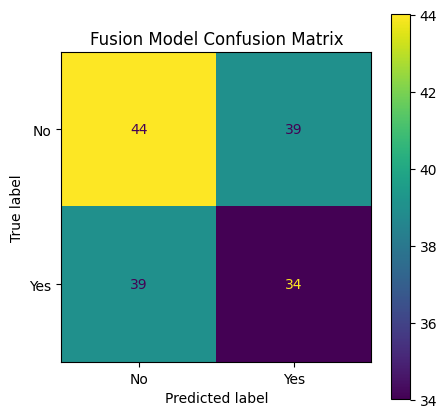

In [57]:
cm_fusion = confusion_matrix(y_test, fusion_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_fusion,
    display_labels=["No", "Yes"]
)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax)

plt.title("Fusion Model Confusion Matrix")

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "confusion_matrix",
        "fusion_model_cm.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
print(fusion_accuracy)

0.5


In [59]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

models_to_try = {
    "Fusion Logistic Regression": LogisticRegression(max_iter=3000, C=0.5, class_weight="balanced", random_state=42),
    "Fusion Linear SVM": LinearSVC(C=0.5, class_weight="balanced", random_state=42),
    "Fusion Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
}

fusion_results = []

for name, model in models_to_try.items():
    model.fit(X_train_fusion, y_train)
    preds = model.predict(X_test_fusion)
    acc = accuracy_score(y_test, preds)
    fusion_results.append([name, acc])
    print(name, "Accuracy:", acc)

fusion_results_df = pd.DataFrame(fusion_results, columns=["Model", "Accuracy"])
fusion_results_df

Fusion Logistic Regression Accuracy: 0.4935897435897436


C:\Users\morij\anaconda3\envs\vqa_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fusion Linear SVM Accuracy: 0.5
Fusion Random Forest Accuracy: 0.47435897435897434


,Model,Accuracy
0,Fusion Logistic Regression,0.493590
1,Fusion Linear SVM,0.500000
2,Fusion Random Forest,0.474359


In [60]:
best_fusion_name = fusion_results_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
best_fusion_acc = fusion_results_df.sort_values("Accuracy", ascending=False).iloc[0]["Accuracy"]

print("Best Fusion Model:", best_fusion_name)
print("Best Fusion Accuracy:", best_fusion_acc)

Best Fusion Model: Fusion Linear SVM
Best Fusion Accuracy: 0.5


In [61]:
text_prob = text_model.predict_proba(X_test_text)[:, 1]
image_prob = image_model.predict_proba(X_test_img)[:, 1]

best_acc = 0
best_weight = 0

for w in np.arange(0.1, 1.0, 0.1):
    combined_prob = (w * text_prob) + ((1 - w) * image_prob)
    combined_pred = (combined_prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, combined_pred)
    
    print(f"Text weight {w:.1f} Accuracy: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_weight = w

print("Best ensemble weight:", best_weight)
print("Best ensemble accuracy:", best_acc)

Text weight 0.1 Accuracy: 0.5064
Text weight 0.2 Accuracy: 0.5064
Text weight 0.3 Accuracy: 0.5064
Text weight 0.4 Accuracy: 0.4872
Text weight 0.5 Accuracy: 0.4808
Text weight 0.6 Accuracy: 0.4808
Text weight 0.7 Accuracy: 0.4808
Text weight 0.8 Accuracy: 0.5192
Text weight 0.9 Accuracy: 0.5192
Best ensemble weight: 0.8
Best ensemble accuracy: 0.5192307692307693


In [62]:
final_results = pd.DataFrame({
    "Model": ["Text Only", "Image Only ResNet18", "Fusion"],
    "Accuracy": [text_accuracy, image_accuracy, fusion_accuracy]
})

final_results

,Model,Accuracy
0,Text Only,0.525641
1,Image Only ResNet18,0.506410
2,Fusion,0.500000


In [63]:
final_results.to_csv(
    os.path.join(PROJECT_DIR, "outputs", "tables", "model_comparison.csv"),
    index=False
)

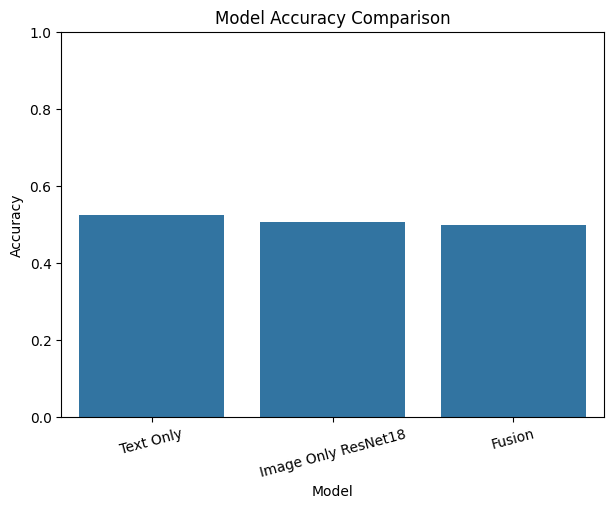

In [64]:
plt.figure(figsize=(7,5))
sns.barplot(data=final_results, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.savefig(
    os.path.join(PROJECT_DIR, "outputs", "figures", "model_accuracy_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
error_analysis_df = test_df.copy()
error_analysis_df["text_prediction"] = text_predictions
error_analysis_df["image_prediction"] = image_predictions
error_analysis_df["fusion_prediction"] = fusion_predictions

error_analysis_df["text_prediction_answer"] = error_analysis_df["text_prediction"].map({0: "no", 1: "yes"})
error_analysis_df["image_prediction_answer"] = error_analysis_df["image_prediction"].map({0: "no", 1: "yes"})
error_analysis_df["fusion_prediction_answer"] = error_analysis_df["fusion_prediction"].map({0: "no", 1: "yes"})

wrong_fusion = error_analysis_df[
    error_analysis_df["label"] != error_analysis_df["fusion_prediction"]
]

wrong_fusion[[
    "image_id",
    "question",
    "answer",
    "fusion_prediction_answer"
]].head(15)

,image_id,question,answer,fusion_prediction_answer
369,562084,is the closest chair occupied?,yes,no
367,548331,are the walkways stones kidney shaped?,no,yes
687,257971,is this man wearing glasses?,no,yes
535,174004,has someone mowed recently?,no,yes
402,474906,is it raining?,no,yes
147,39976,is there an appropriate amount of basil on the...,yes,no
483,304186,does this man have a mustache?,yes,no
25,58123,is this bus turning on red?,no,yes
650,214492,are these men wearing the same styled tie?,no,yes
244,190664,is there traffic light in the background?,yes,no


In [66]:
wrong_fusion.to_csv(
    os.path.join(PROJECT_DIR, "outputs", "predictions", "fusion_wrong_predictions.csv"),
    index=False
)

print("Wrong predictions saved.")

Wrong predictions saved.


In [67]:
import joblib

# Save Text Model
joblib.dump(
    text_model,
    os.path.join(PROJECT_DIR, "models", "text_model", "text_model.pkl")
)

# Save Image Model
joblib.dump(
    image_model,
    os.path.join(PROJECT_DIR, "models", "image_model", "image_model.pkl")
)

# Save Fusion Model
joblib.dump(
    fusion_model,
    os.path.join(PROJECT_DIR, "models", "fusion_model", "fusion_model.pkl")
)

print("All models saved successfully!")

All models saved successfully!


In [68]:
joblib.dump(
    tfidf,
    os.path.join(PROJECT_DIR, "models", "text_model", "tfidf_vectorizer.pkl")
)

print("TF-IDF Vectorizer saved.")

TF-IDF Vectorizer saved.


In [69]:
joblib.dump(
    scaler,
    os.path.join(PROJECT_DIR, "models", "fusion_model", "image_scaler.pkl")
)

print("Scaler saved.")

Scaler saved.


In [71]:
final_results = pd.DataFrame({
    "Model": [
        "Text Only",
        "Image Only (ResNet18)",
        "Fusion"
    ],
    "Accuracy": [
        round(text_accuracy,4),
        round(image_accuracy,4),
        round(fusion_accuracy,4)
    ]
})

final_results

,Model,Accuracy
0,Text Only,0.5256
1,Image Only (ResNet18),0.5064
2,Fusion,0.5000


In [72]:
final_results.to_csv(
    os.path.join(
        PROJECT_DIR,
        "outputs",
        "tables",
        "final_results.csv"
    ),
    index=False
)

In [73]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"Dataset Used              : {len(balanced_df)}")
print(f"Unique Images             : {balanced_df['image_id'].nunique()}")

print("\nModel Performance")

print(f"Text Only Accuracy        : {text_accuracy:.4f}")
print(f"Image Only Accuracy       : {image_accuracy:.4f}")
print(f"Fusion Model Accuracy     : {fusion_accuracy:.4f}")

PROJECT SUMMARY
Dataset Used              : 777
Unique Images             : 545

Model Performance
Text Only Accuracy        : 0.5256
Image Only Accuracy       : 0.5064
Fusion Model Accuracy     : 0.5000


## Evaluation Criteria

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Accuracy is useful because this is a binary classification task.  
Precision, recall, and F1-score are included to check performance for both Yes and No classes.

## Results

| Model | Accuracy |
|---|---:|
| Text-only | 52.56% |
| Image-only ResNet18 | 50.64% |
| Fusion | 50.00% |

The text-only model achieved the highest accuracy. This suggests that the question text contains language patterns that help predict Yes/No answers even without image input.

## Error Analysis and Limitations

The fusion model did not outperform the text-only model.

Possible reasons:

- The dataset subset is small.
- The Yes/No task can contain language bias.
- ResNet18 was used only as a frozen feature extractor.
- Simple concatenation may not be strong enough for visual question reasoning.
- The model does not deeply align image regions with question words.

This supports the project motivation that VQA models can rely on language priors and that stronger image-question grounding is needed.

## Conclusion

This project compared text-only, image-only, and fusion models for Yes/No VQA.

The text-only model achieved the best performance, showing that question patterns alone can provide useful predictive signals.

The fusion model did not improve over the text-only baseline, which suggests that simple feature fusion with a small dataset is not enough for strong visual grounding.

Future work could use a larger dataset, CLIP/BLIP features, attention-based fusion, and full answer classification beyond Yes/No.